In [7]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image

TRAIN_CSV = '/resnick/groups/CS156b/from_central/data/student_labels/train2023.csv'
IMAGE_BASE_DIR = '/resnick/groups/CS156b/from_central/data/train/'

TARGETS = [
    'No Finding',
    'Enlarged Cardiomediastinum',
    'Cardiomegaly',
    'Lung Opacity',
    'Pneumonia',
    'Pleural Effusion',
    'Pleural Other',
    'Fracture',
    'Support Devices',
]

df = pd.read_csv(TRAIN_CSV)
df.head()

,Unnamed: 0.1,Unnamed: 0,Path,Sex,Age,Frontal/Lateral,AP/PA,No Finding,Enlarged Cardiomediastinum,Cardiomegaly,Lung Opacity,Pneumonia,Pleural Effusion,Pleural Other,Fracture,Support Devices
0,0,0,train/pid50512/study1/view1_frontal.jpg,Female,68,Frontal,AP,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0
1,1,1,train/pid21580/study2/view1_frontal.jpg,Female,87,Frontal,AP,-1.0,NaN,0.0,1.0,NaN,0.0,NaN,1.0,NaN
2,2,2,train/pid21580/study1/view1_frontal.jpg,Female,83,Frontal,AP,-1.0,NaN,NaN,1.0,NaN,NaN,NaN,1.0,NaN
3,3,3,train/pid21580/study1/view2_lateral.jpg,Female,83,Lateral,NaN,-1.0,NaN,NaN,1.0,NaN,NaN,NaN,1.0,NaN
4,4,4,train/pid33839/study1/view1_frontal.jpg,Male,41,Frontal,AP,-1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


/tmp/ipykernel_1290239/3181405659.py:3: FutureWarning: The previous implementation of stack is deprecated and will be removed in a future version of pandas. See the What's New notes for pandas 2.1.0 for details. Specify future_stack=True to adopt the new implementation and silence this warning.
  label_long = df[TARGETS].apply(pd.to_numeric, errors='coerce').stack(dropna=False).reset_index()


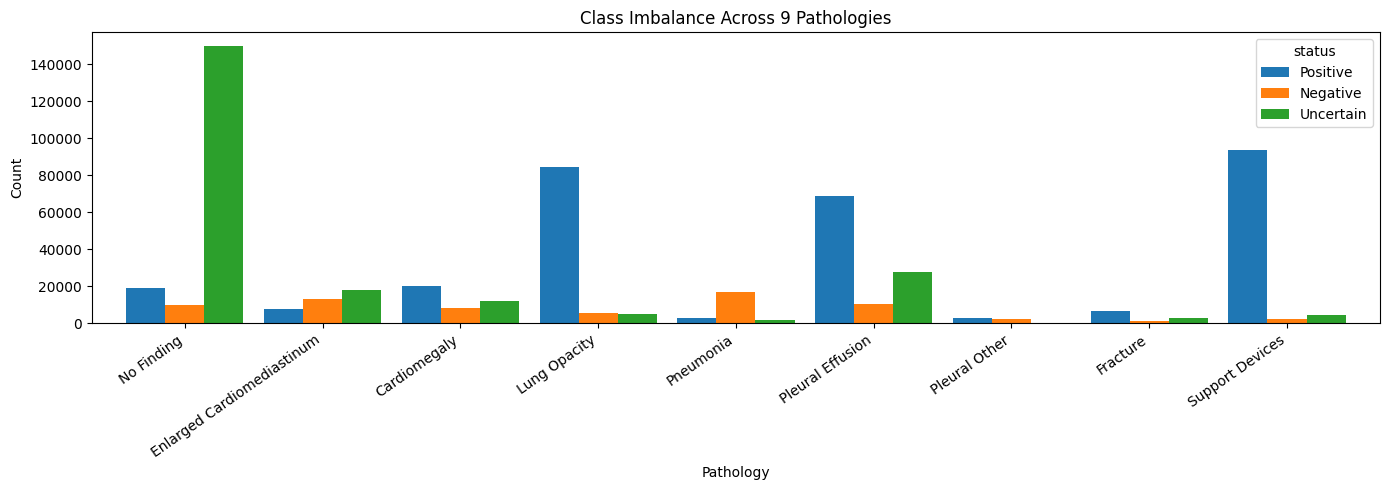

In [8]:
status_map = {1.0: 'Positive', 0.0: 'Negative', -1.0: 'Uncertain'}

label_long = df[TARGETS].apply(pd.to_numeric, errors='coerce').stack(dropna=False).reset_index()
label_long.columns = ['row_id', 'pathology', 'value']
label_long['status'] = label_long['value'].map(status_map)

plot_df = (
    label_long[label_long['status'].isin(['Positive', 'Negative', 'Uncertain'])]
    .groupby(['pathology', 'status'])
    .size()
    .unstack(fill_value=0)
    .reindex(index=TARGETS)
)

plot_df = plot_df[['Positive', 'Negative', 'Uncertain']]
ax = plot_df.plot(kind='bar', figsize=(14, 5), width=0.85)
ax.set_title('Class Imbalance Across 9 Pathologies')
ax.set_xlabel('Pathology')
ax.set_ylabel('Count')
plt.xticks(rotation=35, ha='right')
plt.tight_layout()
plt.show()

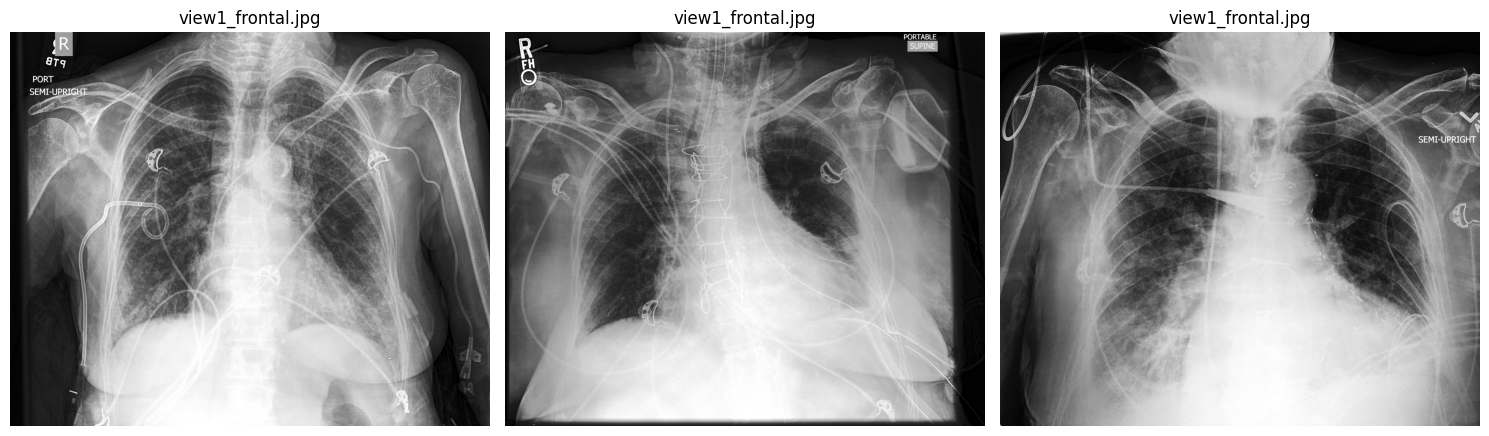

In [9]:
def find_path_column(frame):
    for col in ['Path', 'path', 'image_path', 'Image Index', 'image']:
        if col in frame.columns:
            return col
    raise ValueError('No image path column found in CSV.')

def resolve_path(image_ref):
    if os.path.isabs(image_ref) and os.path.exists(image_ref):
        return image_ref
    candidates = [
        os.path.join(IMAGE_BASE_DIR, image_ref),
        os.path.join(IMAGE_BASE_DIR, image_ref.lstrip('/')),
        os.path.join(os.path.dirname(IMAGE_BASE_DIR.rstrip('/')), image_ref.lstrip('/')),
    ]
    for c in candidates:
        if os.path.exists(c):
            return c
    raise FileNotFoundError(f'Could not resolve image path: {image_ref}')

path_col = find_path_column(df)
candidates = df[path_col].dropna().astype(str).tolist()
sample_count = min(3, len(candidates))
sampled_paths = np.random.default_rng(42).choice(candidates, size=sample_count, replace=False)

fig, axes = plt.subplots(1, sample_count, figsize=(5 * sample_count, 5))
if sample_count == 1:
    axes = [axes]

for ax, p in zip(axes, sampled_paths):
    img = Image.open(resolve_path(p)).convert('L')
    ax.imshow(np.array(img), cmap='gray')
    ax.set_title(os.path.basename(p))
    ax.axis('off')

plt.tight_layout()
plt.show()

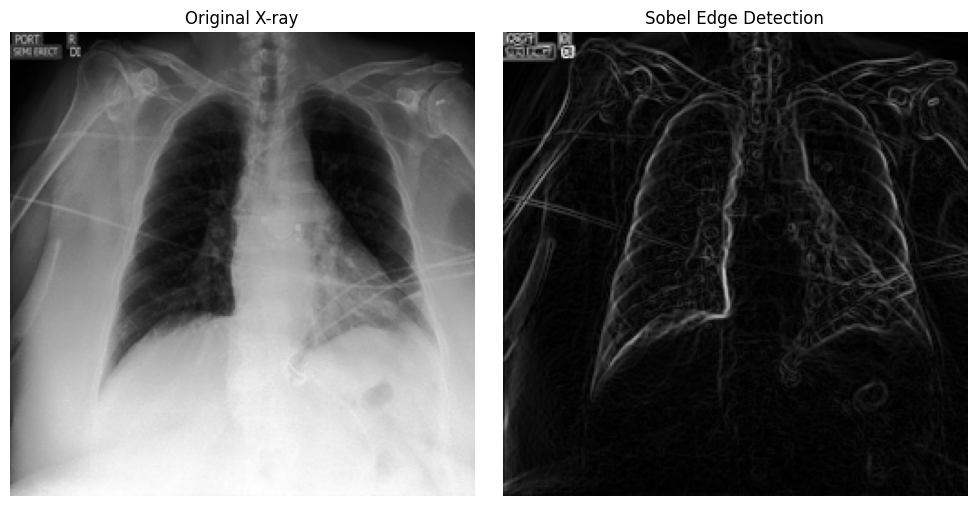

In [10]:
def convolve2d(image, kernel):
    kh, kw = kernel.shape
    ph, pw = kh // 2, kw // 2
    padded = np.pad(image, ((ph, ph), (pw, pw)), mode='edge')
    out = np.zeros_like(image, dtype=np.float32)
    for i in range(image.shape[0]):
        for j in range(image.shape[1]):
            region = padded[i:i + kh, j:j + kw]
            out[i, j] = np.sum(region * kernel)
    return out

sobel_x = np.array([[-1, 0, 1], [-2, 0, 2], [-1, 0, 1]], dtype=np.float32)
sobel_y = np.array([[-1, -2, -1], [0, 0, 0], [1, 2, 1]], dtype=np.float32)

example_ref = str(df[path_col].dropna().iloc[0])
example_img = Image.open(resolve_path(example_ref)).convert('L').resize((256, 256))
img_arr = np.array(example_img, dtype=np.float32)

gx = convolve2d(img_arr, sobel_x)
gy = convolve2d(img_arr, sobel_y)
edges = np.sqrt(gx ** 2 + gy ** 2)
edges = (edges / (edges.max() + 1e-8) * 255.0).astype(np.uint8)

fig, axes = plt.subplots(1, 2, figsize=(10, 5))
axes[0].imshow(img_arr, cmap='gray')
axes[0].set_title('Original X-ray')
axes[0].axis('off')

axes[1].imshow(edges, cmap='gray')
axes[1].set_title('Sobel Edge Detection')
axes[1].axis('off')

plt.tight_layout()
plt.show()